In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("synthetic_stress_dataset.csv")
df.head()

,sleep_hours,meal_quality,screen_time,physical_activity,steps,mood,stress_level
0,6.605620,2.003111,8.808728,1.250564,2941.881219,5.179942,2
1,4.364590,4.450449,7.834033,1.526972,2230.140428,3.571345,2
2,7.380969,6.755345,1.221280,6.496044,10981.548485,7.944415,0
3,7.859966,7.285852,5.285953,3.941311,5951.214145,6.477512,1
4,7.425245,7.786553,3.310908,6.475356,11286.489435,7.840061,0


In [4]:
df.info

<bound method DataFrame.info of       sleep_hours  meal_quality  screen_time  physical_activity         steps  \
0        6.605620      2.003111     8.808728           1.250564   2941.881219   
1        4.364590      4.450449     7.834033           1.526972   2230.140428   
2        7.380969      6.755345     1.221280           6.496044  10981.548485   
3        7.859966      7.285852     5.285953           3.941311   5951.214145   
4        7.425245      7.786553     3.310908           6.475356  11286.489435   
...           ...           ...          ...                ...           ...   
1195     4.399614      4.667584     7.110005           2.775016   6450.767184   
1196     4.866997      2.914929    10.214511           1.624188   5238.134076   
1197     6.201932      4.510546     7.086796           1.787526   6026.675716   
1198     5.273011      2.010432     6.862065           2.012820   6191.900574   
1199     5.346117      5.090417    10.096330           2.126476   6229.609576

In [5]:
df.shape

(1200, 7)

In [6]:
df.describe()

,sleep_hours,meal_quality,screen_time,physical_activity,steps,mood,stress_level
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,6.501863,6.132440,5.031368,3.292090,7444.920665,6.050950,1.000000
std,1.535709,1.854061,2.155115,1.617585,2552.118994,2.000232,0.816837
min,1.778984,1.213032,-0.019512,-0.319611,1448.783520,1.381867,0.000000
25%,5.412122,4.780569,3.279580,1.997434,5496.896297,4.380165,0.000000
50%,6.567614,6.097078,4.899707,3.124000,7544.561874,6.140670,1.000000
75%,7.724574,7.509295,6.702107,4.527708,9303.763570,7.696998,2.000000
max,10.058688,11.193108,11.390905,7.579709,14618.321213,11.852731,2.000000


In [7]:
# Fix negative values in screen_time and physical_activity
# We replace any value less than 0 with 0
df['screen_time'] = df['screen_time'].clip(lower=0)
df['physical_activity'] = df['physical_activity'].clip(lower=0)

In [8]:
# meal_quality/mood should strictly be max 10, clip them too
df['meal_quality'] = df['meal_quality'].clip(upper=10)
df['mood'] = df['mood'].clip(upper=10)

In [9]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 sleep_hours          0
meal_quality         0
screen_time          0
physical_activity    0
steps                0
mood                 0
stress_level         0
dtype: int64


In [10]:
# Renaming columns for simplicity
df.columns = [
    'sleep_hours', 'meal_quality', 'screen_time',
    'physical_activity', 'steps', 'mood', 'stress'
]

In [12]:

df.describe()

,sleep_hours,meal_quality,screen_time,physical_activity,steps,mood,stress
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,6.501863,6.126882,5.031384,3.292799,7444.920665,6.046771,1.000000
std,1.535709,1.841137,2.155077,1.616091,2552.118994,1.990893,0.816837
min,1.778984,1.213032,0.000000,0.000000,1448.783520,1.381867,0.000000
25%,5.412122,4.780569,3.279580,1.997434,5496.896297,4.380165,0.000000
50%,6.567614,6.097078,4.899707,3.124000,7544.561874,6.140670,1.000000
75%,7.724574,7.509295,6.702107,4.527708,9303.763570,7.696998,2.000000
max,10.058688,10.000000,11.390905,7.579709,14618.321213,10.000000,2.000000


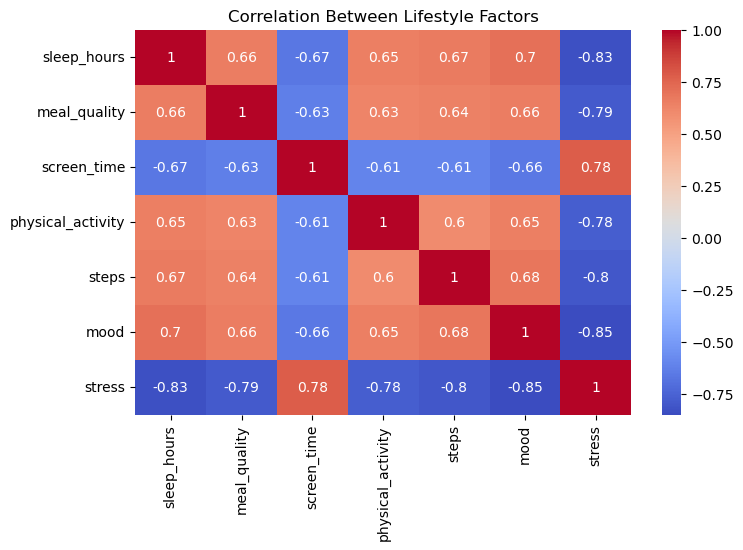

In [13]:
# =======================
# 6️⃣ Correlation Matrix
# =======================
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Lifestyle Factors")
plt.show()

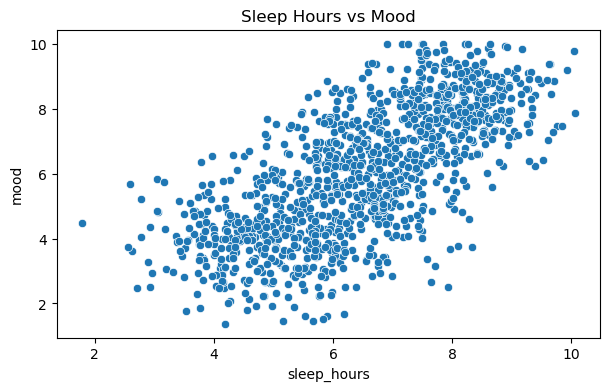

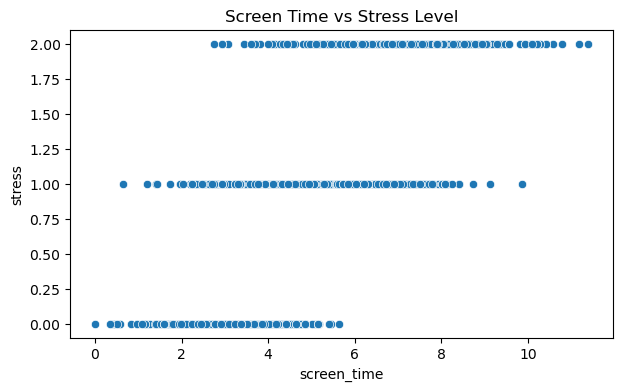

In [14]:
# =======================
# 7️⃣ Basic Insights
# =======================
plt.figure(figsize=(7,4))
sns.scatterplot(x='sleep_hours', y='mood', data=df)
plt.title("Sleep Hours vs Mood")
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(x='screen_time', y='stress', data=df)
plt.title("Screen Time vs Stress Level")
plt.show()

In [15]:
# Define Features (X) and Target (y)
X = df[['sleep_hours', 'meal_quality', 'screen_time', 'physical_activity', 'steps', 'mood']]
y = df['stress']  # Assuming 0=Low, 1=Normal, 2=High

In [21]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine back into DataFrames to save them as CSV
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Save to CSV files (index=False prevents adding an extra index column)
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

print("Success! 'train.csv' and 'test.csv' have been created.")

Success! 'train.csv' and 'test.csv' have been created.


Correlation between Steps and Physical Activity: 0.60


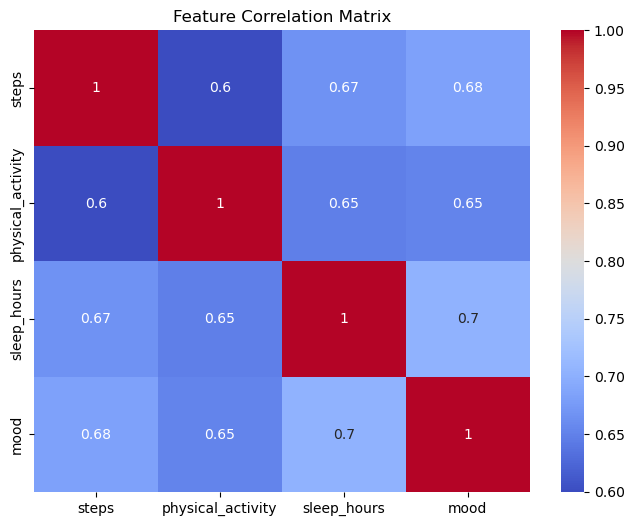

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
# df = pd.read_csv('your_dataset.csv') 

# Check specific correlation
correlation = df['steps'].corr(df['physical_activity'])
print(f"Correlation between Steps and Physical Activity: {correlation:.2f}")

# Visual Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['steps', 'physical_activity', 'sleep_hours', 'mood']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Text(0.5, 0, 'Meal Quality Score')

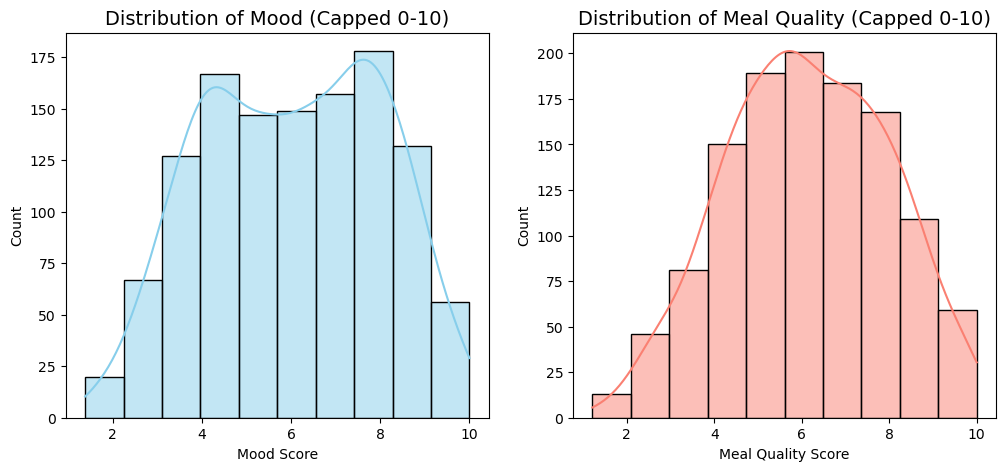

In [23]:


# --- PLOT 2: Feature Distribution (The "Data Cleaning" Proof) ---
# This shows that Mood and Meal Quality are safely within 0-10
plt.figure(figsize=(12, 5))

# Create subplots for Mood and Meal Quality
plt.subplot(1, 2, 1)
sns.histplot(df['mood'], kde=True, color='skyblue', bins=10)
plt.title('Distribution of Mood (Capped 0-10)', fontsize=14)
plt.xlabel('Mood Score')

plt.subplot(1, 2, 2)
sns.histplot(df['meal_quality'], kde=True, color='salmon', bins=10)
plt.title('Distribution of Meal Quality (Capped 0-10)', fontsize=14)
plt.xlabel('Meal Quality Score')





In [ ]:

# --- PLOT 3: Stress Level vs. Sleep (The "Insight" Plot) ---
# A Boxplot to show how sleep varies across stress levels
plt.figure(figsize=(8, 6))
sns.boxplot(x='stress', y='sleep_hours', data=df, palette="Set2")
plt.title('Sleep Hours vs. Stress Level', fontsize=16)
plt.xlabel('Stress Level (0=Low, 1=Normal, 2=High)', fontsize=12)
plt.ylabel('Sleep Hours', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
